# 1D Heat Equation via Finite Volume Method

This notebook imports the solver from `heat_equation_fvm.py` and computes the time evolution of the 1D heat equation, $u_t = \kappa u_{xx}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import heat_equation_fvm

CFL number = 5.00000e-01
Computed temperature on 100 cells and 2000 time steps.
Time step dt = 5.00000e-05
Heat flux array shape: (2001, 101)


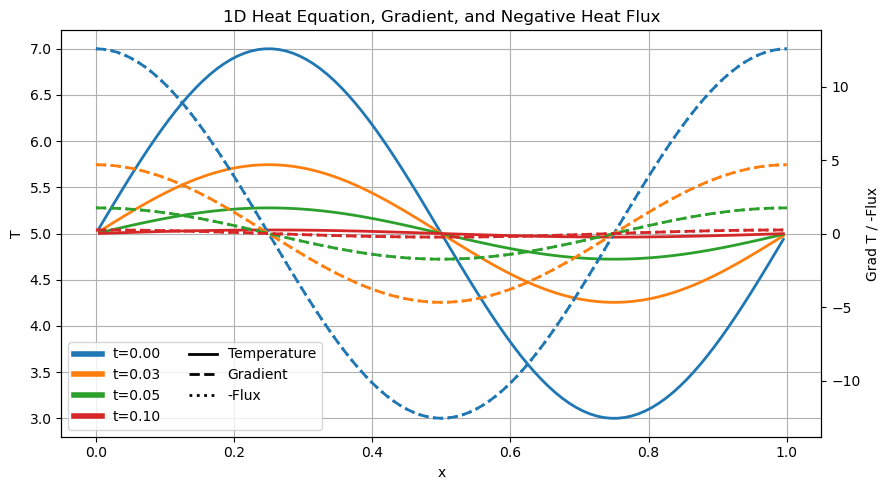

In [79]:
# Parameters for the finite volume solver
nx = 100
nt = 2000
t_end = 0.1
kappa = 1
length = 1.0
left_bc = 1.0
right_bc = 2.0

dx = length / nx
dt = t_end / nt
cfl = kappa * dt / dx**2
print(f'CFL number = {cfl:.5e}')

# Reload the module to get the latest changes
importlib.reload(heat_equation_fvm)

initial_condition = heat_equation_fvm.sinusoidal_initial_condition
flux              = heat_equation_fvm.saturated_heat_flux

x, times, temperatures, gradients, heat_fluxes = heat_equation_fvm.solve_heat_equation_fvm(
    nx=nx,
    nt=nt,
    t_end=t_end,
    length=length,
    kappa=kappa,
    left_bc=left_bc,
    right_bc=right_bc,
    initial_condition=initial_condition,
    flux=flux,
    periodic=True,
    )

print(f'Computed temperature on {nx} cells and {nt} time steps.')
print(f'Time step dt = {t_end/nt:.5e}')
print(f'Heat flux array shape: {heat_fluxes.shape}')

selected_indices = [0, len(times)//4, len(times)//2, -1]
x_faces = np.linspace(0.0, length, gradients.shape[1])

fig, ax_temp = plt.subplots(figsize=(9, 5))
ax_grad = ax_temp.twinx()

time_colors = []
for idx in selected_indices:
    temp = temperatures[idx]
    (temp_line,) = ax_temp.plot(x, temp, '-', linewidth=2)
    color = temp_line.get_color()
    time_colors.append((idx, color))
    ax_grad.plot(x_faces, gradients[idx], '--', color=color, linewidth=2)
    ax_grad.plot(x_faces, -heat_fluxes[idx], ':', color=color, linewidth=2)

ax_temp.set_xlabel('x')
ax_temp.set_ylabel('T', color='black')
ax_grad.set_ylabel('Grad T / -Flux', color='black')
ax_temp.set_title('1D Heat Equation, Gradient, and Negative Heat Flux')
ax_temp.grid(True)

from matplotlib.lines import Line2D

time_handles = [
    Line2D([0], [0], color=color, linewidth=4, linestyle='-', label=f't={times[idx]:.2f}')
    for idx, color in time_colors
]
style_handles = [
    Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Temperature'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Gradient'),
    Line2D([0], [0], color='black', linewidth=2, linestyle=':', label='-Flux'),
]
ax_temp.legend(handles=time_handles + style_handles, ncol=2, loc='lower left')

plt.tight_layout()
plt.show()

Detected mode: 1
A0     = 2
decay  = 19.7522
phase  = 2.39577e-16
offset = 5
RMS error = 1.17416e-15


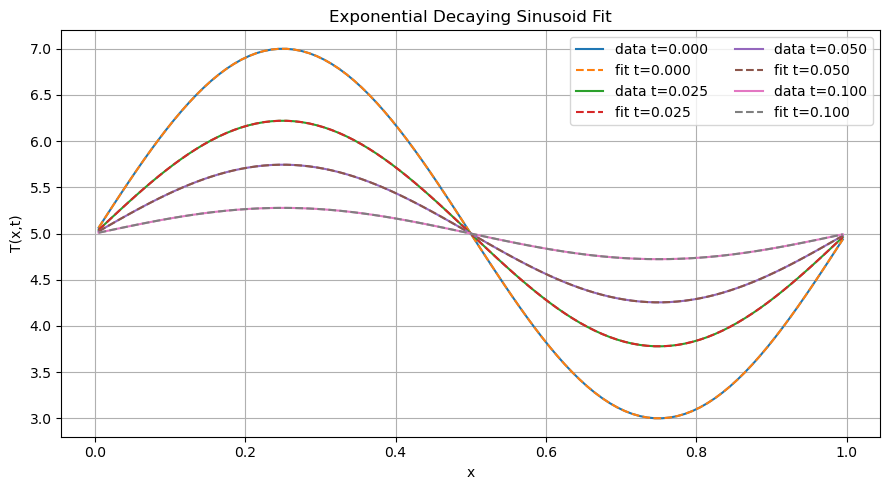

In [66]:
from scipy.optimize import curve_fit

# Fit model: T(x,t) = offset + A0 * exp(-decay * t) * sin(2*pi*mode*x/length + phase)
# Estimate dominant spatial mode from the initial condition.
initial_profile = temperatures[0] - np.mean(temperatures[0])
fft_mag = np.abs(np.fft.rfft(initial_profile))
if len(fft_mag) < 2 or np.allclose(fft_mag[1:], 0):
    raise RuntimeError("Could not detect a sinusoidal mode from the data.")
mode_guess = int(np.argmax(fft_mag[1:]) + 1)

X, T = np.meshgrid(x, times)
x_flat = X.ravel()
t_flat = T.ravel()
y_flat = temperatures.ravel()


def exp_decay_sine_xt(x_t, A0, decay, phase, offset):
    x_vals, t_vals = x_t
    return offset + A0 * np.exp(-decay * t_vals) * np.sin(2 * np.pi * mode_guess * x_vals / length + phase)

A0_guess = 0.5 * (np.max(temperatures[0]) - np.min(temperatures[0]))
decay_guess = max(kappa * (2 * np.pi * mode_guess / length) ** 2, 1e-8)
phase_guess = 0.0
offset_guess = float(np.mean(temperatures))

p0 = [A0_guess, decay_guess, phase_guess, offset_guess]
bounds = ([-np.inf, 0.0, -2 * np.pi, -np.inf], [np.inf, np.inf, 2 * np.pi, np.inf])

params, _ = curve_fit(
    exp_decay_sine_xt,
    (x_flat, t_flat),
    y_flat,
    p0=p0,
    bounds=bounds,
    maxfev=20000,
)

A0_fit, decay_fit, phase_fit, offset_fit = params
fitted = exp_decay_sine_xt((X, T), A0_fit, decay_fit, phase_fit, offset_fit)
rms_error = np.sqrt(np.mean((fitted - temperatures) ** 2))

print(f"Detected mode: {mode_guess}")
print(f"A0     = {A0_fit:.6g}")
print(f"decay  = {decay_fit:.6g}")
print(f"phase  = {phase_fit:.6g}")
print(f"offset = {offset_fit:.6g}")
print(f"RMS error = {rms_error:.6g}")

# Visual comparison at selected times
selected = [0, len(times)//4, len(times)//2, -1]
plt.figure(figsize=(9, 5))
for idx in selected:
    plt.plot(x, temperatures[idx], '-', label=f"data t={times[idx]:.3f}")
    plt.plot(x, fitted[idx], '--', label=f"fit t={times[idx]:.3f}")
plt.xlabel('x')
plt.ylabel('T(x,t)')
plt.title('Exponential Decaying Sinusoid Fit')
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import multiprocessing as mp
import shutil
import subprocess


def _save_frame(args):
    frame_index, temp, grad, neg_flux, t_value, x_vals, x_faces_vals, temp_lim, gradflux_lim, out_dir = args
    fig, ax_temp = plt.subplots(figsize=(8, 4))
    ax_grad = ax_temp.twinx()

    ax_temp.plot(x_vals, temp, color="tab:blue", linewidth=2, label="Temperature")
    ax_grad.plot(x_faces_vals, grad, color="tab:orange", linewidth=2, label="Gradient")
    ax_grad.plot(x_faces_vals, neg_flux, color="tab:green", linewidth=2, label="-Flux")

    ax_temp.set_xlim(0.0, float(length))
    ax_temp.set_ylim(*temp_lim)
    ax_grad.set_ylim(*gradflux_lim)
    ax_temp.set_xlabel("x")
    ax_temp.set_ylabel("T(x, t)")
    ax_grad.set_ylabel("Grad T / -Flux")
    ax_temp.set_title(f"1D Heat Equation at t={t_value:.4f}")
    ax_temp.grid(True)

    lines_temp, labels_temp = ax_temp.get_legend_handles_labels()
    lines_grad, labels_grad = ax_grad.get_legend_handles_labels()
    ax_temp.legend(lines_temp + lines_grad, labels_temp + labels_grad, loc="lower left")

    fig.savefig(Path(out_dir) / f"frame_{frame_index:04d}.png", dpi=120)
    plt.close(fig)


frames_dir = Path("frames")
frames_dir.mkdir(exist_ok=True)

x_faces = np.linspace(0.0, float(length), gradients.shape[1])
temp_lim = (float(np.min(temperatures)), float(np.max(temperatures)))
gradflux_vals = np.concatenate([gradients.ravel(), (-heat_fluxes).ravel()])
gradflux_lim = (float(np.min(gradflux_vals)), float(np.max(gradflux_vals)))

jobs = [
    (
        idx,
        temperatures[idx],
        gradients[idx],
        -heat_fluxes[idx],
        float(times[idx]),
        x,
        x_faces,
        temp_lim,
        gradflux_lim,
        str(frames_dir),
    )
    for idx in range(len(times))
]

num_workers = mp.cpu_count()
ctx = mp.get_context("fork")
with ctx.Pool(processes=num_workers) as pool:
    pool.map(_save_frame, jobs)

print(f"Saved {len(jobs)} frames to {frames_dir.resolve()} using {num_workers} cores")


frames_dir = Path("frames")
output_movie = Path("heat_solution.mp4")

if not frames_dir.exists():
    raise FileNotFoundError(f"Frames directory not found: {frames_dir.resolve()}")

if shutil.which("ffmpeg") is None:
    raise RuntimeError("ffmpeg is not installed or not found on PATH.")

subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-framerate", "20",
        "-i", str(frames_dir / "frame_%04d.png"),
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        str(output_movie),
    ],
    check=True,
)

print(f"Saved movie to {output_movie.resolve()}")

Saved 1001 frames to /Users/tylertrent/Documents/GitHub/HeatDispersion_FiniteVolume/frames using 14 cores


ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with clang version 12.0.0
  configuration: --prefix=/Users/ktietz/demo/mc3/conda-bld/ffmpeg_1628925491858/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=arm64-apple-darwin20.0.0-clang --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57

Saved movie to /Users/tylertrent/Documents/GitHub/HeatDispersion_FiniteVolume/heat_solution.mp4


frame= 1001 fps=633 q=-1.0 Lsize=     338kB time=00:00:49.90 bitrate=  55.4kbits/s speed=31.5x    
video:325kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 3.860646%
[libx264 @ 0x14b02d600] frame I:5     Avg QP:14.31  size: 17470
[libx264 @ 0x14b02d600] frame P:269   Avg QP:21.13  size:   590
[libx264 @ 0x14b02d600] frame B:727   Avg QP:30.77  size:   118
[libx264 @ 0x14b02d600] consecutive B-frames:  0.6%  7.4%  0.9% 91.1%
[libx264 @ 0x14b02d600] mb I  I16..4: 61.2% 22.7% 16.1%
[libx264 @ 0x14b02d600] mb P  I16..4:  0.1%  0.0%  0.0%  P16..4:  1.6%  0.3%  0.3%  0.0%  0.0%    skip:97.7%
[libx264 @ 0x14b02d600] mb B  I16..4:  0.0%  0.1%  0.0%  B16..8:  0.8%  0.1%  0.0%  direct: 0.0%  skip:98.9%  L0:47.8% L1:50.3% BI: 1.9%
[libx264 @ 0x14b02d600] 8x8 transform intra:26.9% inter:19.0%
[libx264 @ 0x14b02d600] coded y,uvDC,uvAC intra: 10.7% 9.8% 9.0% inter: 0.2% 0.2% 0.2%
[libx264 @ 0x14b02d600] i16 v,h,dc,p: 74% 20%  6%  0%
[libx264 @ 0x14b02d600] i8 v,h,dc,d

In [ ]:
# Compute fractional differences from initial state
initial_state = temperatures[0]
fractional_diffs = np.array([(temp - initial_state) / np.where(initial_state != 0, initial_state, 1) for temp in temperatures])

# Compute average, min, and max fractional difference for each time step
median_fractional_diff = np.median(np.abs(fractional_diffs), axis=1)
min_fractional_diff = np.min(np.abs(fractional_diffs), axis=1)
max_fractional_diff = np.max(np.abs(fractional_diffs), axis=1)

# Plot median, min, and max fractional differences vs time
plt.figure(figsize=(8, 5))
plt.plot(times, median_fractional_diff, label='Median |fractional difference|')
plt.plot(times, min_fractional_diff, label='Min |fractional difference|')
plt.plot(times, max_fractional_diff, label='Max |fractional difference|')
plt.xlabel('Time')
plt.ylabel('Fractional Difference')
plt.title('Fractional Difference from Initial Temperature vs Time')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
# Plot spatial distribution of fractional differences at selected times
selected_time_indices = [0, len(times)//4, len(times)//2, -1]
plt.figure(figsize=(8, 5))
for idx in selected_time_indices:
    plt.plot(x, fractional_diffs[idx], label=f't={times[idx]:.3f}')
plt.xlabel('x')
plt.ylabel('Fractional Difference')
plt.title('Spatial Distribution of Fractional Differences')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()